In [1]:
import bw2data, bw2io, bw2calc
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime
import os
import re
import pandas as pd
import numpy as np
import pickle

In [2]:
import sys
sys.path.append('../utils/') 
from elec_builder import *

In [3]:
# activate the bw project
bw2data.projects.set_current("ei311")

### 1. build up foreground (static)
#### for CN reservoir, using RoW as proxy
#### for US reservoir, using CA-QC as proxy, then replace with Annie's CH4 / CO2 values in AB

##### build only ONE ACT in each database 

In [4]:
# for CN reservoir, using RoW as proxy
hydro_qc = ["CA-QC"]
hydro_row = ['RoW']

pathways = [ "SSP1-VLLO" , "SSP2-M", "SSP5-H" ]
years = [2030, 2040, 2050]

for ssp in pathways:
    for year in years:

        fg_db_name = (
                f"elec_hydro_reservoir_foreground_"
                f"CN_{ssp}_{year}"
        )

        act = build_dynamic_electricity_all(
                locations   = hydro_row,
                pathways    = [ssp],    #make sure it's a list 
                years       = [year],   #make sure it's a list 
                elec_act   = "electricity production, hydro, reservoir, non-alpine region",
                ref_name   = "market for electricity, hydro, high voltage",
                fg_db_name = fg_db_name,
                flush_fg_db = True,
        )



Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2030'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2030'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2040'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2040'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2050'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP1-VLLO_2050'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2030'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2030'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2040'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2040'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2050'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_CN_SSP2-M_2050'
Flushing existing fore

In [5]:
# now for US
for ssp in pathways:
    for year in years:

        fg_db_name = (
                f"elec_hydro_reservoir_foreground_"
                f"US_{ssp}_{year}"
        )

        act = build_dynamic_electricity_all(
                locations   = hydro_qc,
                pathways    = [ssp],    #make sure it's a list 
                years       = [year],   #make sure it's a list 
                elec_act   = "electricity production, hydro, reservoir, non-alpine region",
                ref_name   = "market for electricity, hydro, high voltage",
                fg_db_name = fg_db_name,
                flush_fg_db = True,
        )


Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2030'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2030'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2040'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2040'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2050'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP1-VLLO_2050'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2030'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2030'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2040'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2040'
Flushing existing foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2050'
Created fresh foreground DB: 'elec_hydro_reservoir_foreground_US_SSP2-M_2050'
Flushing existing fore

#### still one final database to check if BW2_timex differs when using ONE-ACT-only Foreground vs. many-ACT Foreground

In [9]:
hydro_all = ["CA-QC", 'RoW']

xx = build_dynamic_electricity_all(
    locations = hydro_all, 
    pathways = [ "SSP1-VLLO" , "SSP2-M", "SSP5-H" ],
    years = [2030,  2050], 
    elec_act = 'electricity production, hydro, reservoir, non-alpine region', #'electricity production, hydro, run-of-river',
    ref_name = 'market for electricity, hydro, high voltage',
    fg_db_name="elec_hydro_reservoir_foreground",
    flush_fg_db = True
)

Created fresh foreground DB: 'elec_hydro_reservoir_foreground'


In [10]:
hydro_db = bw2data.Database("elec_hydro_reservoir_foreground")
list(hydro_db)

['market for electricity, hydro, high voltage, RoW, SSP5-H, 2050' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, RoW, SSP5-H, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' (kWh, RoW, None),
 'market for electricity, hydro, high volta

In [11]:
rows = []   # collect results for all acts
act_list = list(hydro_db)   
for act in act_list: 
    print(act)

    name = act.get("name")
    name_parts = [p.strip() for p in name.split(",")]
    # run static LCI + premise_GWP vs. pGWP100 first: 
    pgwp_fixedco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - fixed-AGWPCO2")
    pgwp_dpco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - dp-AGWPCO2")
    gwp =  ('ecoinvent-3.11', 'IPCC 2021 (incl. biogenic CO2)', 'climate change: total (incl. biogenic CO2, incl. SLCFs)', 'global warming potential (GWP100)')   

    lca_gwp = bw2calc.lca.LCA({act: 1}, method=gwp)
    lca_gwp.lci(); lca_gwp.lcia()
    score_gwp = float(lca_gwp.score)

    lca_fixed = bw2calc.lca.LCA({act: 1}, method=pgwp_fixedco2)
    lca_fixed.lci(); lca_fixed.lcia()
    score_fixedco2 = float(lca_fixed.score)

    lca_dp = bw2calc.lca.LCA({act: 1}, method=pgwp_dpco2)
    lca_dp.lci(); lca_dp.lcia()
    score_dpco2 = float(lca_dp.score)

    print(score_gwp, score_fixedco2, score_dpco2) 

    # ---- store results for this activity ----
    rows.append({
        "Activity": name,                      # index value later
        "gwp100": score_gwp,
        "pGWP100_fixedCO2": score_fixedco2,
        "pGWP100_dpCO2": score_dpco2,
    })


'market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2030' (kWh, CA-QC, None)
0.027292939932888418 0.028536060092229244 0.02591865003637973
'market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2050' (kWh, RoW, None)
0.047436732219880984 0.05397883122767464 0.04740242110869345
'market for electricity, hydro, high voltage, RoW, SSP5-H, 2030' (kWh, RoW, None)
0.050766200890030054 0.05473736040770803 0.049735442519686236
'market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2050' (kWh, CA-QC, None)
0.02707391746799039 0.02403169664360956 0.026579363786423633
'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' (kWh, RoW, None)
0.04984367713503863 0.04970105204671182 0.0499302471063752
'market for electricity, hydro, high voltage, RoW, SSP5-H, 2050' (kWh, RoW, None)
0.05038793265576484 0.04519818412313044 0.05000602597456853
'market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2030' (kWh, CA-QC, None)
0.027237480987037523 0.029438320034113258 0.02

In [12]:
df_scores = pd.DataFrame(rows)
df_scores = df_scores.set_index("Activity")

df2 = df_scores.sort_values(by=['Activity'])
df2

,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2
Activity,,,
"market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2030",0.027212,0.030422,0.026565
"market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2050",0.025149,0.028633,0.025134
"market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2030",0.027237,0.029438,0.026299
"market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2050",0.026952,0.026994,0.027105
"market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2030",0.027293,0.028536,0.025919
"market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2050",0.027074,0.024032,0.026579
"market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2030",0.050523,0.057266,0.050021
"market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2050",0.047437,0.053979,0.047402
"market for electricity, hydro, high voltage, RoW, SSP2-M, 2030",0.050624,0.055848,0.049911


##### w/o updating with Annie's CO2/CH4 value: 

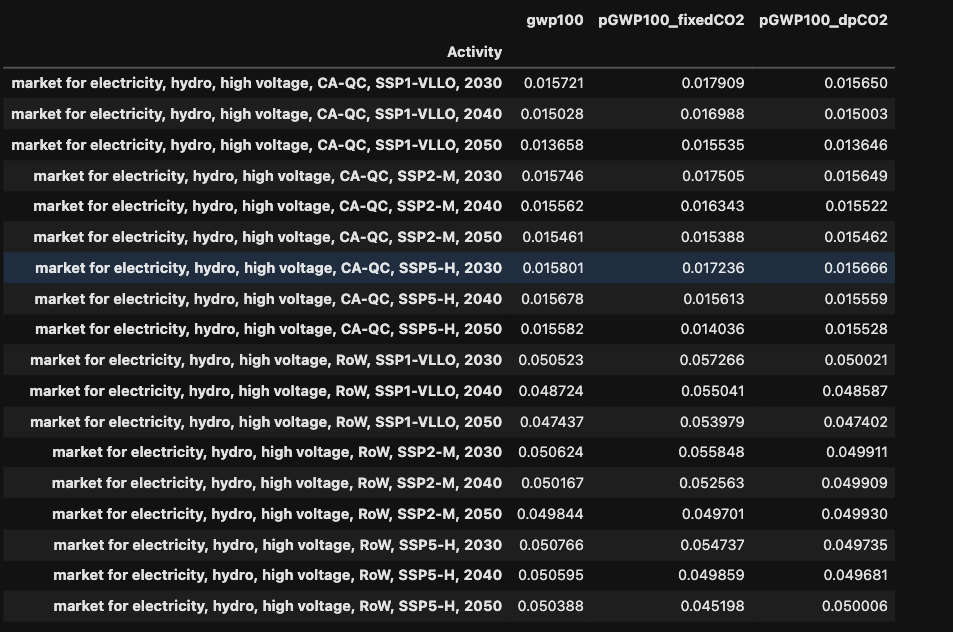

In [13]:
df2.index = df2.index.str.replace("RoW", "CN", regex=False)
df2.index = df2.index.str.replace("CA-QC", "US", regex=False)
df2

,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2
Activity,,,
"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",0.027212,0.030422,0.026565
"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",0.025149,0.028633,0.025134
"market for electricity, hydro, high voltage, US, SSP2-M, 2030",0.027237,0.029438,0.026299
"market for electricity, hydro, high voltage, US, SSP2-M, 2050",0.026952,0.026994,0.027105
"market for electricity, hydro, high voltage, US, SSP5-H, 2030",0.027293,0.028536,0.025919
"market for electricity, hydro, high voltage, US, SSP5-H, 2050",0.027074,0.024032,0.026579
"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",0.050523,0.057266,0.050021
"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",0.047437,0.053979,0.047402
"market for electricity, hydro, high voltage, CN, SSP2-M, 2030",0.050624,0.055848,0.049911


In [14]:
df2.to_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")

### 2. building dpLCI

In [15]:
hydro_db = bw2data.Database("elec_hydro_reservoir_foreground")
list(hydro_db)

['market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2050' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP1-VLLO, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, RoW, SSP5-H, 2050' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2030' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP5-H, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high voltage, RoW, SSP5-H, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, RoW, SSP1-VLLO, 2030' (kWh, RoW, None),
 'market for electricity, hydro, high voltage, CA-QC, SSP2-M, 2050' (kWh, CA-QC, None),
 'market for electricity, hydro, high vo

In [16]:
hydro_db_203050 = [
    act for act in hydro_db 
    if "2050" in str(act.get('name', '')) or  "2030" in str(act.get('name', ''))
]

In [17]:
database_dates = {
    'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22': datetime.strptime("2050", "%Y"),
    
    "elec_hydro_reservoir_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

In [18]:
dp_results = {}

for act in list(hydro_db_203050): 
    print(act)
 
    #### dynamic LCI:: 
    assign_td_from_foreground_db( 
        select_act = act,
        elec_td_year=10,
        resolution="Y",
        kind="uniform",
        fg_db_name="elec_hydro_reservoir_foreground",
        verbose = True
     )

    tlca = run_dp_timex_lca(foreground_act = act ,   
                    pathway = None,
                    year = None,
                    method = None,
                    database_dates = database_dates, #None not working, has to incl. all 9 background DB ... 
                    temporal_grouping="year", 
                    method_prefix = "Climate Change prospective GWP100",
                    method_suffix = "pGWP100 - fixed-AGWPCO2", 
                    fg_db_name = 'elec_hydro_reservoir_foreground'
     )

    tlca.lci()
    tlca.dynamic_inventory.shape

    # dyn-foreground LCI + static background LCI + pGWP100
    lca_0 = tlca.base_score 
    print(lca_0)
    # dpLCI (dyn-foreground LCI + dyn background LCI) +  pGWP100
    tlca.static_lcia()
    lca_1 = tlca.static_score
    print(lca_1)

    act_name = act.get("name")
    dp_results[act_name] = {
        "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": float(lca_0),   # static BG LCI + dyn FG LCI
        "full dp-LCI, pGWP100-fixedCO2": float(lca_1),      # dyn BG LCI + dyn FG LCI
    }

    #### now save all dyLCI flows to pandas 
    df = tlca.dynamic_inventory_df

    ##### important to convert flow and act as str to excel 
    df["flow"] = df["flow"].astype(str)
    df["activity"] = df["activity"].astype(str)

    ### export df to dp-LCI_output folder, using the act name as the excel name 
    out_dir = "dp-LCI_output/hydro_dpLCI_v2_reservoir"
    os.makedirs(out_dir, exist_ok=True)    
    raw_name = act["name"]
    safe_name = re.sub(r"[^A-Za-z0-9_\-()]+", "_", raw_name)   # replace spaces/special chars
    
    excel_path = os.path.join(out_dir, f"{safe_name}.xlsx")
    
    df.to_excel(excel_path, index=False)    
    print(f"✔ Exported dynamic inventory DF for '{raw_name}' → {excel_path}")


import pickle

out_dir = "dp-LCI_output/hydro_dpLCI_v2_reservoir"
os.makedirs(out_dir, exist_ok=True)

pickle_path = os.path.join(out_dir, "hydro_v2_reservoir_dp_results_MY2030_2050.pkl")

with open(pickle_path, "wb") as f:
    pickle.dump(dp_results, f)

print(f"✔ Saved dp_results dictionary → {pickle_path}")

2025-12-21 21:22:21.750 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2025-12-21 21:22:21.752 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' (kWh, RoW, None)
TD applied to 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' → Exchange: 1 kilowatt hour 'electricity production, hydro, reservoir, non-alpine region' (kilowatt hour, RoW, None) to 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' (kWh, RoW, None)>
for the activity 'market for electricity, hydro, high voltage, RoW, SSP2-M, 2050' (kWh, RoW, None),it's under SSP-SSP2-M, year-2050 
 we'll use LCIA ('Climate Change prospective GWP100', 'SSP245', 'MY2050', 'pGWP100 - fixed-AGWPCO2')  with background database.datetime = {'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.datetime(2040, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.datetime(2050, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11_ima

2025-12-21 21:25:15.074 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2025-12-21 21:26:47.372 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2025-12-21 21:27:11.019 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2025-12-21 21:27:13.817 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...


Starting graph traversal


2025-12-21 21:27:15.546 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...


...

Starting graph traversal


2025-12-21 23:34:00.735 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...


Calculation count: 1


2025-12-21 23:34:00.953 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-21 23:34:00.955 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-21 23:34:00.956 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-21 23:34:00.961 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2028-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-21 23:34:00.962 | INFO     | bw_time

0.045198184123130467
0.04550740872852547
✔ Exported dynamic inventory DF for 'market for electricity, hydro, high voltage, RoW, SSP5-H, 2050' → dp-LCI_output/hydro_dpLCI_v2_reservoir/market_for_electricity_hydro_high_voltage_RoW_SSP5-H_2050.xlsx
✔ Saved dp_results dictionary → dp-LCI_output/hydro_dpLCI_v2_reservoir/hydro_v2_reservoir_dp_results_MY2030_2050.pkl
